### Computer Vision (OpenCV & scikit-image) ###
* Edge Detection (Canny): Highlights the boundaries of objects by finding rapid changes in pixel intensity.

* Keypoint Detection (SIFT/ORB): Identifies unique points (corners or blobs) that are invariant to scale and rotation, useful for matching two images.

* Texture Analysis (LBP/HOG): Uses Local Binary Patterns (LBP) or Histogram of Oriented Gradients (HOG) to describe the "feel" or structural shape of an image.

* Histogram Comparison: Captures the distribution of intensities across the image


Convert random sample image to array

In [2]:
import os
import random
from PIL import Image
import numpy as np

random.seed(42)

# image directory
img_files = r"../data/license_plate_detection/test/images"

# list files 
files = os.listdir(img_files)

# get random sample from files
test_file = os.path.join(img_files, random.sample(files, k=1)[0]) 

# open test file, convert to grayscale and convert to numpy array
img = Image.open(test_file)
gs_img = img.convert("L")
image_arr = np.asarray(gs_img)

**Edge Detection (Canny):** Highlights the boundaries of objects by finding rapid changes in pixel intensity.

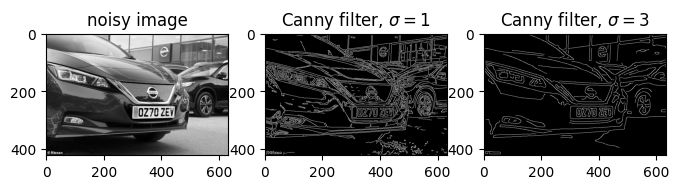

In [3]:
import matplotlib.pyplot as plt
from skimage import feature
%matplotlib inline

# determine edges based on different std dev values
# higher std dev means larger gradient, less edges

edges1 = feature.canny(image_arr)
edges2 = feature.canny(image_arr, sigma=3)

# display results
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(8, 3))

ax[0].imshow(image_arr, cmap='gray')
ax[0].set_title('noisy image')

ax[1].imshow(edges1, cmap='gray')
ax[1].set_title(r'Canny filter, $\sigma=1$')

ax[2].imshow(edges2, cmap='gray')
ax[2].set_title(r'Canny filter, $\sigma=3$')

plt.show()


**Keypoint Detection (SIFT/ORB):** Identifies unique points (corners or blobs) that are invariant to scale and rotation, useful for matching two images

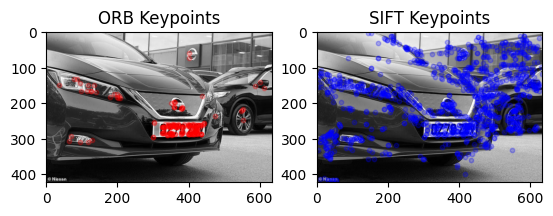

In [4]:

from skimage.feature import ORB, SIFT 
import matplotlib.pyplot as plt

# define orb extractor
orb_descriptor_extractor = ORB(n_keypoints=200)

# get ORB keypoints and descriptors from image
orb_descriptor_extractor.detect_and_extract(image_arr)
orb_keypoints = orb_descriptor_extractor.keypoints
orb_descriptors = orb_descriptor_extractor.descriptors

# define ORB coordinates for sample plot
x_coords_orb = orb_keypoints[:, 1]
y_coords_orb = orb_keypoints[:, 0]

# define SIFT extractor
sift_descriptor_extractor = SIFT()

# get SIFT keypoints and descriptors from image
sift_descriptor_extractor.detect_and_extract(image_arr)
sift_keypoints = sift_descriptor_extractor.keypoints
sift_descriptors = sift_descriptor_extractor.descriptors

# define SIFT coordinates for sample plot
x_coords_sift = sift_keypoints[:, 1]
y_coords_sift = sift_keypoints[:, 0]

# plot coordinates
fig, axes = plt.subplots(1,2)

axes[0].imshow(image_arr, cmap = "gray")
axes[0].set_title('ORB Keypoints')
axes[1].imshow(image_arr, cmap = "gray")
axes[1].set_title('SIFT Keypoints')
axes[0].scatter(x_coords_orb, y_coords_orb, label = "ORB keypoints", color = "red", s = 10, alpha = 0.25)
axes[1].scatter(x_coords_sift, y_coords_sift, label = "SIFT keypoints", color = "blue", s= 10,  alpha = 0.25)

plt.show()

**Texture Analysis (LBP):** Local Binary Patterns: Comparison of central pixel to its surrounding neighbors; if a neighbor's intensity is greater than or equal to the center, it's marked as 1, otherwise 0. These bits are then concatenated into a binary number and converted to decimal.

* P = Number of Neighbors
* R = Radius of Circle

Text(0.5, 1.0, 'Original Image')

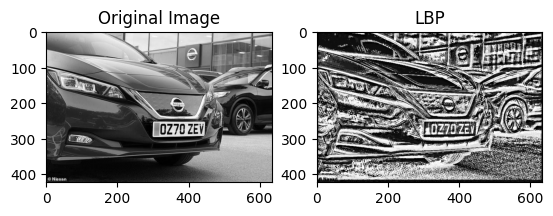

In [5]:
from skimage.feature import local_binary_pattern
P, R = 8,8
# Basic Syntax
lbp_image = local_binary_pattern(image_arr, P, R, method='default')

fig, axes = plt.subplots(1,2)

axes[1].imshow(lbp_image, cmap = "gray")
axes[1].set_title('LBP')
axes[0].imshow(image_arr, cmap = "gray")
axes[0].set_title('Original Image')

**Histogram of Oriented Gradients:** Image is divided into small cells and a 9-bin histogram of gradient directions is calculated for each, spanning 0 to 180.

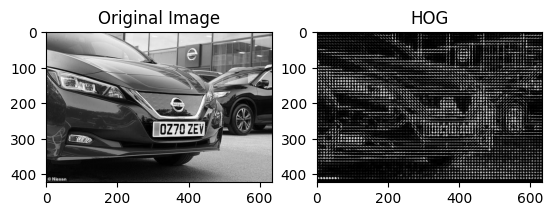

In [6]:
from skimage.feature import hog
from skimage import exposure
# Extract HOG features and a visualization image
fd, hog_image = hog(img, 
                    orientations=9, 
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), 
                    visualize=True, 
                    channel_axis=-1)

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1,2)

axes[1].imshow(hog_image_rescaled, cmap = "gray")
axes[1].set_title('HOG')
axes[0].imshow(image_arr, cmap = "gray")
axes[0].set_title('Original Image')

plt.show()

**Histogram Comparison:** Histogram comparison using calc_hist and compare_hist from cv2 package. Compare hisograms to determine similarity or dissimilarity between two images

Correlation (Similarity): 0.7292
Intersection (Similarity): 66.1374
Chi-Square (Distance/Dissimilarity): 27.1883
Bhattacharyya (Distance/Dissimilarity): 0.1668


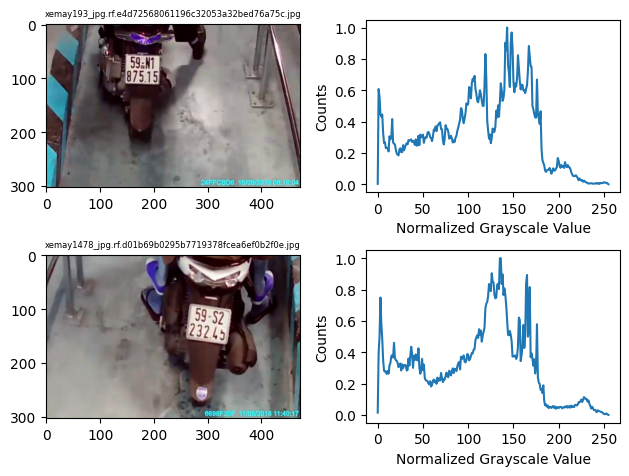

In [15]:
import cv2
def compare_images(image_path1, image_path2):
    # 1. Load images
    img1 = cv2.imread(image_path1)
    img2 = cv2.imread(image_path2)
    
    if img1 is None or img2 is None:
        raise FileNotFoundError("One or both image paths are invalid.")

    # convert to HSV color space (better for color/lighting variations)
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # calculate histograms
    hist1 = cv2.calcHist([gray1], [0], None, [256], [0, 256])
    hist2 = cv2.calcHist([gray2], [0], None, [256], [0, 256])

    # normalize histograms (Crucial if images have different pixel counts)
    cv2.normalize(hist1, hist1, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    cv2.normalize(hist2, hist2, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    # compare using different metrics
    corr = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
    chisq = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CHISQR)
    intersect = cv2.compareHist(hist1, hist2, cv2.HISTCMP_INTERSECT)
    bhattacharyya = cv2.compareHist(hist1, hist2, cv2.HISTCMP_BHATTACHARYYA)

    # print results
    print(f"Correlation (Similarity): {corr:.4f}")
    print(f"Intersection (Similarity): {intersect:.4f}")
    print(f"Chi-Square (Distance/Dissimilarity): {chisq:.4f}")
    print(f"Bhattacharyya (Distance/Dissimilarity): {bhattacharyya:.4f}")

    
    fig, axes = plt.subplots(2,2)

    axes[0][0].imshow(img1)
    axes[0][0].set_title(image_path1.split("\\")[-1], fontsize = 6)

    axes[0][1].plot(hist1)
    axes[0][1].set_xlabel("Normalized Grayscale Value")
    axes[0][1].set_ylabel("Counts")
    
    axes[1][0].set_title(image_path2.split("\\")[-1],fontsize = 6)
    axes[1][0].imshow(img2)

    axes[1][1].plot(hist2)
    axes[1][1].set_xlabel("Normalized Grayscale Value")
    axes[1][1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()


tf1 = r"../data/license_plate_detection/test/images\xemay193_jpg.rf.e4d72568061196c32053a32bed76a75c.jpg"
tf2 = r"../data/license_plate_detection/test/images\xemay1478_jpg.rf.d01b69b0295b7719378fcea6ef0b2f0e.jpg"

compare_images(tf1, tf2)

**Compare Two Different Sample Images (More Dissimilar)**

Correlation (Similarity): 0.2425
Intersection (Similarity): 7.0455
Chi-Square (Distance/Dissimilarity): 64.0473
Bhattacharyya (Distance/Dissimilarity): 0.3839


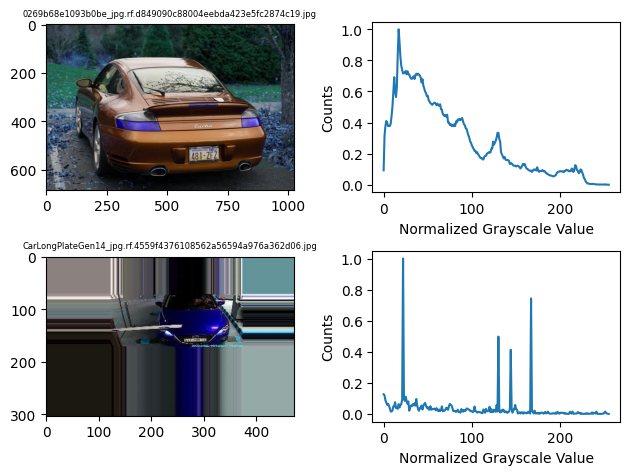

In [8]:
test_file1 = os.path.join(img_files, random.sample(files, k=3)[1]) 
test_file2 = os.path.join(img_files, random.sample(files, k=3)[2]) 

compare_images(test_file1, test_file2)